# End-to-End Institutional Portfolio Risk Analysis & Risk Decomposition
# Author: Angelos Kesidis | Role: Junior Quant Analyst
# Objective: Assess the risk-return profile, correlation dynamics,
#             and diversification benefits of a 4-asset institutional portfolio.

In [1]:
# --- 1. IMPORTING LIBRARIES & DEPENDENCIES ---
import numpy as np
import pandas as pd
import yfinance as yf
import random
import math as m
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. DEFINING THE PORTFOLIO ---
# Selecting 4 large-cap stocks across different GICS sectors to test diversification:
# JPM: Financials | WMT: Defensive (Retail) | CVX: Energy | AMZN: Technology / Cyclical
tickers = ["JPM", "WMT", "CVX", "AMZN"]

# Client Allocation Weights: AMZN (40%), JPM (20%), WMT (20%), CVX (20%)
weights = np.array([0.2, 0.2, 0.2, 0.4])

# --- 3. DATA EXTRACTION ---
# Fetching historical daily closing prices from Yahoo Finance
stocks = yf.download(tickers, start="2019-01-01")

# Displaying data structure to ensure data integrity
print("--- Data Head ---")
print(stocks.head(10))
print("\n--- Data Tail ---")
print(stocks.tail(10))
print("\n--- Data Info ---")
print(stocks.info())

[*********************100%***********************]  4 of 4 completed

--- Data Head ---
Price           Close                                        High             \
Ticker           AMZN        CVX        JPM        WMT       AMZN        CVX   
Date                                                                           
2019-01-02  76.956497  80.604248  81.250206  27.967043  77.667999  81.325163   
2019-01-03  75.014000  79.060455  80.095497  27.823225  76.900002  81.041155   
2019-01-04  78.769501  80.698921  83.048264  27.997011  79.699997  80.822714   
2019-01-07  81.475502  81.747498  83.106003  28.326593  81.727997  82.235389   
2019-01-08  82.829002  81.390694  82.949280  28.524353  83.830498  82.861657   
2019-01-09  82.971001  82.482994  82.809074  28.431469  83.389999  83.014581   
2019-01-10  82.810997  82.614075  82.800819  28.452450  83.162498  82.745151   
2019-01-11  82.028000  81.951401  82.404900  28.416487  83.014503  82.322783   
2019-01-14  80.860497  81.354301  83.254440  28.449451  82.410004  81.805781   
2019-01-15  83.727997 

## Part 1: Historical Performance & Price Normalization
## Visualizing the historical performance of the assets by normalizing their starting baseline to 100.

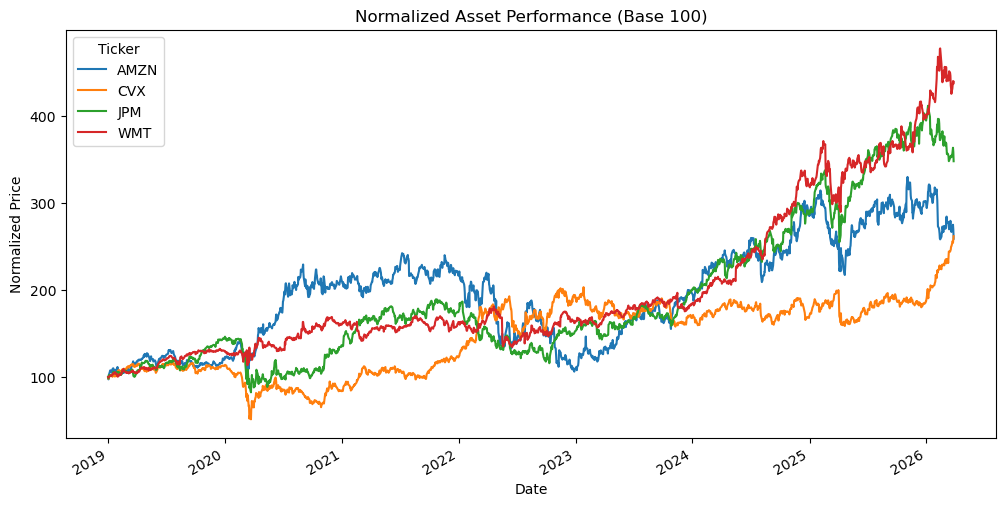

In [2]:
# Normalizing prices (Base 100) for comparative performance visualization
normalization_chart = (stocks["Close"] / stocks["Close"].iloc[0] * 100)
normalization_chart.plot(figsize=(12,6))
plt.title("Normalized Asset Performance (Base 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.show()

## Part 2: Logarithmic Returns & Asset Volatility
## Calculating continuous compounding returns and assessing the standalone risk (Standard Deviation) of each asset.

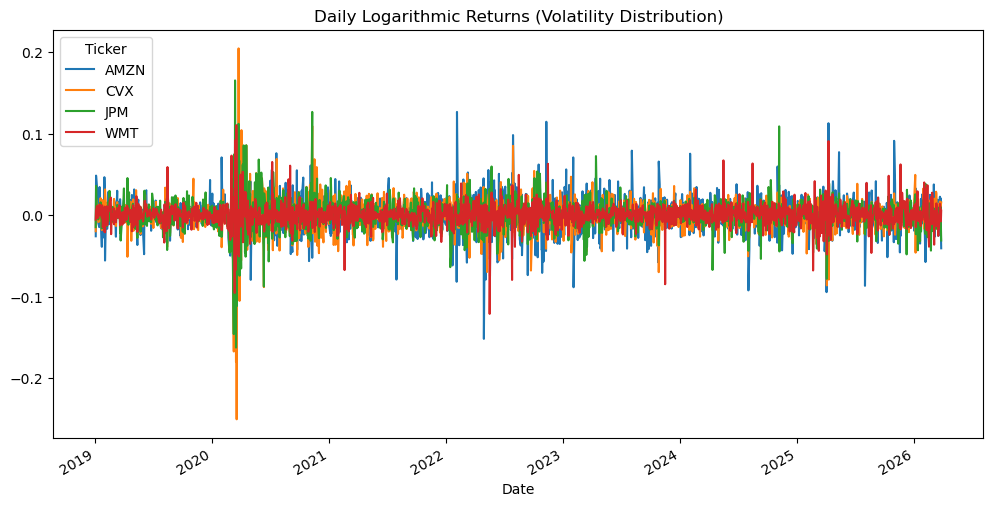

Annual Returns:
 Ticker
AMZN    13.09
CVX     13.24
JPM     17.15
WMT     20.36
dtype: float64

Annual Variance:
 Ticker
AMZN    0.115
CVX     0.103
JPM     0.088
WMT     0.048
dtype: float64

Annual Standard Deviation:
 Ticker
AMZN    33.92
CVX     32.09
JPM     29.60
WMT     22.00
dtype: float64

--- Annualized Risk & Return Profile ---
        Expected Return (%)  Standard Deviation (Risk) (%)
Ticker                                                    
AMZN                  13.09                          33.92
CVX                   13.24                          32.09
JPM                   17.15                          29.60
WMT                   20.36                          22.00


In [3]:
# Calculating daily logarithmic returns
log_return = np.log(stocks["Close"] / stocks["Close"].shift(1))

# Visualizing daily return volatility
log_return.plot(figsize=(12,6))
plt.title("Daily Logarithmic Returns (Volatility Distribution)")
plt.show()

# Annualizing returns and variance (Assuming 250 trading days)
annual_returns = log_return.mean() * 250
print("Annual Returns:\n", round(annual_returns*100, 2))

annual_variance = log_return.var() * 250
print("\nAnnual Variance:\n", round(annual_variance, 3))

# Annualizing Standard Deviation (Standalone Risk)
annual_stdev = log_return.std() * (250 ** 0.5)
print("\nAnnual Standard Deviation:\n", round(annual_stdev*100, 2))

# Compiling Risk-Return metrics into a DataFrame for clear presentation
data = {
    "Expected Return (%)": annual_returns,
    "Standard Deviation (Risk) (%)": annual_stdev
}
df_metrics = pd.DataFrame(data)
print("\n--- Annualized Risk & Return Profile ---")
print(round(df_metrics * 100, 2))

# ANALYST INSIGHT:
# For a risk-averse client, WMT is the optimal standalone choice. 
# It offers the highest return (20.36%) with the lowest predictable risk (22.00%). 
# Based on the empirical rule (68% probability / 1 Std Dev), WMT's annual return 
# is expected to fluctuate between 42.36% and -1.64%.

## Part 3: Correlation & Covariance Matrix
## Evaluating the co-movement of the assets to determine the portfolio's diversification efficiency.

--- Annualized Covariance Matrix ---
Ticker    AMZN     CVX     JPM     WMT
Ticker                                
AMZN    0.1151  0.0199  0.0310  0.0206
CVX     0.0199  0.1030  0.0564  0.0124
JPM     0.0310  0.0564  0.0876  0.0165
WMT     0.0206  0.0124  0.0165  0.0484

--- Variance Sanity Check ---
Ticker
AMZN    0.1151
CVX     0.1030
JPM     0.0876
WMT     0.0484
dtype: float64

--- Correlation Matrix ---
Ticker    AMZN     CVX     JPM     WMT
Ticker                                
AMZN    1.0000  0.1830  0.3091  0.2764
CVX     0.1830  1.0000  0.5935  0.1750
JPM     0.3091  0.5935  1.0000  0.2536
WMT     0.2764  0.1750  0.2536  1.0000


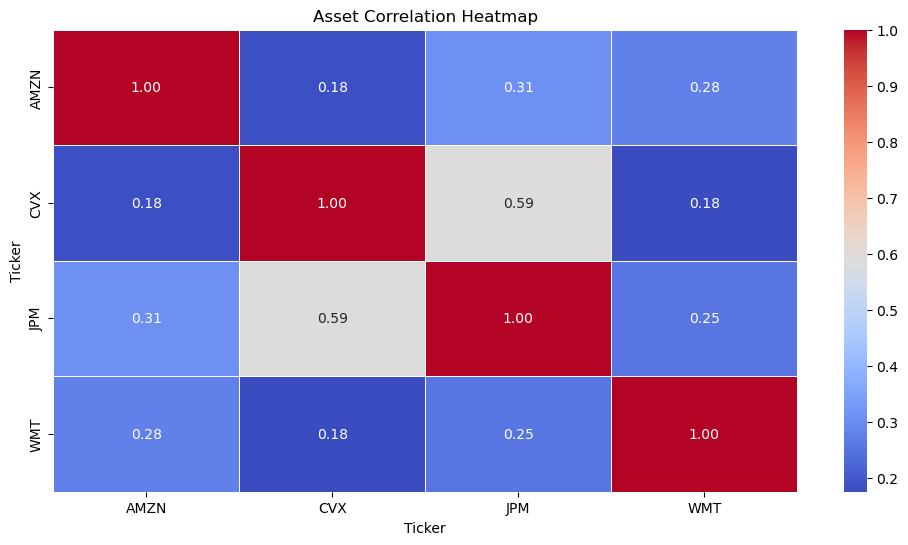

In [4]:
# Calculating the Annualized Covariance Matrix
annual_covariance = log_return.cov() * 250
print("--- Annualized Covariance Matrix ---")
print(round(annual_covariance, 4))

# Sanity Check: Variance vs Covariance Matrix diagonal
print("\n--- Variance Sanity Check ---")
print(round(annual_variance, 4))

# Calculating the Correlation Matrix (r) - Not annualized as it is time-independent
correlation_matrix = log_return.corr()
print("\n--- Correlation Matrix ---")
print(round(correlation_matrix, 4))

# Generating a Correlation Heatmap for visual analysis
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)   
plt.title("Asset Correlation Heatmap")
plt.show()

# ANALYST INSIGHT:
# 1. High Correlation: JPM and CVX show a strong positive correlation (r = 0.59). 
#    They tend to move in the same direction, driven by broader macroeconomic cycles.
# 2. Low Correlation (Diversification Benefit): CVX and WMT, as well as CVX and AMZN, 
#    show very slight positive correlation (r = 0.18). Their movements are largely independent.

## Part 4: Total Portfolio Risk & Risk Decomposition
## Applying Matrix Algebra (Linear Algebra) to calculate total portfolio variance, and decomposing it into Systematic (Market) Risk and Diversifiable (Idiosyncratic) Risk.

In [5]:
# --- STEP A: TOTAL PORTFOLIO RISK ---
# Using NumPy Dot Product for Matrix Multiplication: W.T * Covariance Matrix * W
portfolio_variance = np.dot(weights.T, np.dot(annual_covariance, weights))
portfolio_volatility = portfolio_variance ** 0.5

print(f"Total Portfolio Variance: {round(portfolio_variance, 3)}")
print(f"Total Portfolio Volatility (Risk): {round(portfolio_volatility * 100, 2)}%\n")

# ANALYST INSIGHT:
# The 4-stock portfolio—given the specific weight allocation—carries a total 
# assumed risk (portfolio volatility) of approximately 19.1%.


# --- STEP B: RISK DECOMPOSITION ---
# Calculating standalone annualized variance for each asset
annual_var_JPM = log_return["JPM"].var() * 250
annual_var_WMT = log_return["WMT"].var() * 250
annual_var_CVX = log_return["CVX"].var() * 250
annual_var_AMZN = log_return["AMZN"].var() * 250

# 1. Calculating Systematic Risk (Weighted standalone variances)
sr = (weights[0]**2 * annual_var_JPM) + (weights[1]**2 * annual_var_WMT) + \
     (weights[2]**2 * annual_var_CVX) + (weights[3]**2 * annual_var_AMZN)

# 2. Calculating Diversifiable (Idiosyncratic) Risk
dr = portfolio_variance - sr

print(f"Systematic Risk Component: {round(sr, 3)}")
print(f"Diversifiable Risk Component: {round(dr, 3)}")

# Ultimate Sanity Check: Does Systematic + Diversifiable equal Total Variance?
sanity_check = round(dr + sr, 5) == round(portfolio_variance, 5)
print(f"\nRisk Decomposition Sanity Check (dr + sr == Total Variance): {sanity_check}")

Total Portfolio Variance: 0.036
Total Portfolio Volatility (Risk): 19.1%

Systematic Risk Component: 0.028
Diversifiable Risk Component: 0.009

Risk Decomposition Sanity Check (dr + sr == Total Variance): True


In [6]:
summary = """
## Part 5: Executive Summary & Investment Strategy
Based on the quantitative analysis of the portfolio spanning from 2019 to present, the following conclusions are drawn:

**1. Expected Return Calculation:**
Factoring in the specific capital allocation weights, the expected annual return of the overall portfolio is calculated as follows:
* AMZN: 13.09% x 0.40 = 5.236%
* CVX:  13.24% x 0.20 = 2.648%
* JPM:  17.15% x 0.20 = 3.430%
* WMT:  20.36% x 0.20 = 4.072%
* Total Expected Portfolio Return: ~15.39%
...
"""
print(summary)


## Part 5: Executive Summary & Investment Strategy
Based on the quantitative analysis of the portfolio spanning from 2019 to present, the following conclusions are drawn:

**1. Expected Return Calculation:**
Factoring in the specific capital allocation weights, the expected annual return of the overall portfolio is calculated as follows:
* AMZN: 13.09% x 0.40 = 5.236%
* CVX:  13.24% x 0.20 = 2.648%
* JPM:  17.15% x 0.20 = 3.430%
* WMT:  20.36% x 0.20 = 4.072%
* Total Expected Portfolio Return: ~15.39%
...

